In [1]:
import os
from pathlib import Path
import csv

# ----------------------------
# CONFIG
# ----------------------------
ROOT_DIR = Path(r"E:\ImageRetrieval\Professions_125k_ISCO_Aligned")  # change if needed
OUTPUT_CSV = ROOT_DIR / "validity_summary.csv"

# ----------------------------
# HELPERS
# ----------------------------
def count_lines(file_path):
    if not file_path.exists():
        return 0
    with open(file_path, "r", encoding="utf-8") as f:
        return sum(1 for line in f if line.strip())

# ----------------------------
# PROCESS
# ----------------------------
overall_valid = 0
overall_invalid = 0
rows = []

for subdir in ROOT_DIR.iterdir():
    if not subdir.is_dir():
        continue

    valid_file = subdir / "valid.txt"
    invalid_file = subdir / "invalid.txt"

    valid_count = count_lines(valid_file)
    invalid_count = count_lines(invalid_file)
    total_count = valid_count + invalid_count

    if total_count == 0:
        valid_pct = 0
        invalid_pct = 0
    else:
        valid_pct = (valid_count / total_count) * 100
        invalid_pct = (invalid_count / total_count) * 100

    overall_valid += valid_count
    overall_invalid += invalid_count

    rows.append([
        subdir.name,
        valid_count,
        invalid_count,
        total_count,
        round(valid_pct, 4),
        round(invalid_pct, 4),
    ])

# ----------------------------
# OVERALL SUMMARY
# ----------------------------
overall_total = overall_valid + overall_invalid

if overall_total > 0:
    overall_valid_pct = (overall_valid / overall_total) * 100
    overall_invalid_pct = (overall_invalid / overall_total) * 100
else:
    overall_valid_pct = 0
    overall_invalid_pct = 0

rows.append([
    "OVERALL",
    overall_valid,
    overall_invalid,
    overall_total,
    round(overall_valid_pct, 4),
    round(overall_invalid_pct, 4),
])

# ----------------------------
# WRITE CSV
# ----------------------------
with open(OUTPUT_CSV, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow([
        "profession",
        "valid_count",
        "invalid_count",
        "total_count",
        "valid_percent",
        "invalid_percent",
    ])
    writer.writerows(rows)

print(f"Saved summary to: {OUTPUT_CSV}")

Saved summary to: E:\ImageRetrieval\Professions_125k_ISCO_Aligned\validity_summary.csv


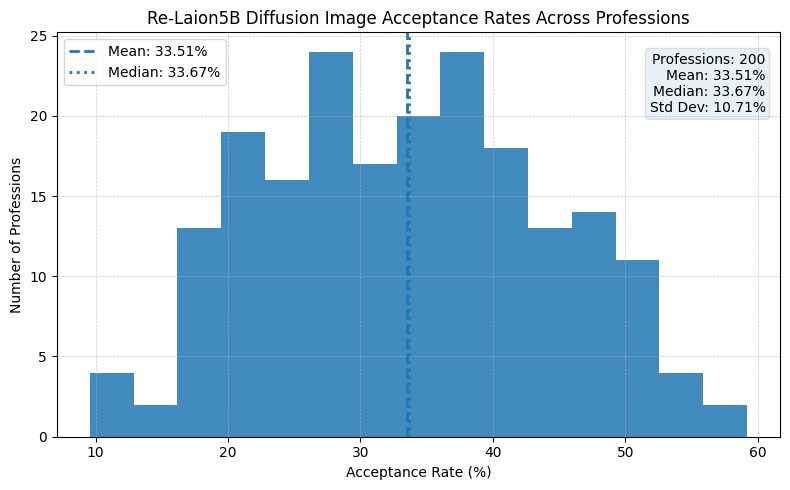

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np

# ----------------------------
# CONFIG — CHANGE THIS PATH
# ----------------------------
ROOT_DIR = Path(r"E:\ImageRetrieval\Professions_125k_ISCO_Aligned")

# ----------------------------
# HELPERS
# ----------------------------
def count_lines(file_path):
    if not file_path.exists():
        return 0
    with open(file_path, "r", encoding="utf-8") as f:
        return sum(1 for line in f if line.strip())

def clean_profession_name(folder_name):
    name = re.sub(r"^A_photo_of_an?_", "", folder_name)
    name = name.replace("_", " ")
    return name.title()

# ----------------------------
# PROCESS
# ----------------------------
data = []

for subdir in ROOT_DIR.iterdir():
    if not subdir.is_dir():
        continue

    valid_file = subdir / "valid.txt"
    invalid_file = subdir / "invalid.txt"

    valid_count = count_lines(valid_file)
    invalid_count = count_lines(invalid_file)
    total_count = valid_count + invalid_count

    if total_count == 0:
        continue

    acceptance_rate = (valid_count / total_count) * 100
    profession_clean = clean_profession_name(subdir.name)

    data.append((profession_clean, acceptance_rate))

df = pd.DataFrame(data, columns=["profession", "acceptance_rate"])

# ----------------------------
# STATISTICS
# ----------------------------
mean_val = df["acceptance_rate"].mean()
median_val = df["acceptance_rate"].median()
std_val = df["acceptance_rate"].std()

# ----------------------------
# HISTOGRAM (Thesis-Grade)
# ----------------------------
plt.figure(figsize=(8, 5))

plt.hist(df["acceptance_rate"], bins=15, alpha=0.85)

# Mean and Median lines
plt.axvline(mean_val, linestyle="--", linewidth=2, label=f"Mean: {mean_val:.2f}%")
plt.axvline(median_val, linestyle=":", linewidth=2, label=f"Median: {median_val:.2f}%")

plt.xlabel("Acceptance Rate (%)")
plt.ylabel("Number of Professions")
plt.title("Re-Laion5B Diffusion Image Acceptance Rates Across Professions")

plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.legend()

# Add small stats box
stats_text = (
    f"Professions: {len(df)-1}\n"
    f"Mean: {mean_val:.2f}%\n"
    f"Median: {median_val:.2f}%\n"
    f"Std Dev: {std_val:.2f}%"
)

plt.text(
    0.98,
    0.95,
    stats_text,
    transform=plt.gca().transAxes,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(boxstyle="round", alpha=0.1)
)

plt.tight_layout()
plt.show()

In [4]:
from pathlib import Path
import csv

# ----------------------------
# CONFIG
# ----------------------------
ROOT_DIR = Path(r"E:\ImageRetrieval\StableDiffusionGeneratedImages")
VALID_DIR = ROOT_DIR / "valid"
INVALID_DIR = ROOT_DIR / "invalid"
OUTPUT_CSV = ROOT_DIR / "validity_summary.csv"

# ----------------------------
# HELPERS
# ----------------------------
def count_images(folder_path):
    if not folder_path.exists():
        return 0
    return sum(1 for f in folder_path.iterdir() if f.is_file())

# ----------------------------
# PROCESS
# ----------------------------
overall_valid = 0
overall_invalid = 0
rows = []

# professions = union of valid and invalid subfolders
profession_names = set()

if VALID_DIR.exists():
    profession_names.update(p.name for p in VALID_DIR.iterdir() if p.is_dir())

if INVALID_DIR.exists():
    profession_names.update(p.name for p in INVALID_DIR.iterdir() if p.is_dir())

for profession in sorted(profession_names):

    valid_count = count_images(VALID_DIR / profession)
    invalid_count = count_images(INVALID_DIR / profession)

    total_count = valid_count + invalid_count

    if total_count == 0:
        valid_pct = 0
        invalid_pct = 0
    else:
        valid_pct = (valid_count / total_count) * 100
        invalid_pct = (invalid_count / total_count) * 100

    overall_valid += valid_count
    overall_invalid += invalid_count

    rows.append([
        profession,
        valid_count,
        invalid_count,
        total_count,
        round(valid_pct, 4),
        round(invalid_pct, 4),
    ])

# ----------------------------
# OVERALL
# ----------------------------
overall_total = overall_valid + overall_invalid

if overall_total > 0:
    overall_valid_pct = (overall_valid / overall_total) * 100
    overall_invalid_pct = (overall_invalid / overall_total) * 100
else:
    overall_valid_pct = 0
    overall_invalid_pct = 0

rows.append([
    "OVERALL",
    overall_valid,
    overall_invalid,
    overall_total,
    round(overall_valid_pct, 4),
    round(overall_invalid_pct, 4),
])

# ----------------------------
# WRITE CSV
# ----------------------------
with open(OUTPUT_CSV, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow([
        "profession",
        "valid_count",
        "invalid_count",
        "total_count",
        "valid_percent",
        "invalid_percent",
    ])
    writer.writerows(rows)

print(f"Saved summary to: {OUTPUT_CSV}")

Saved summary to: E:\ImageRetrieval\StableDiffusionGeneratedImages\validity_summary.csv


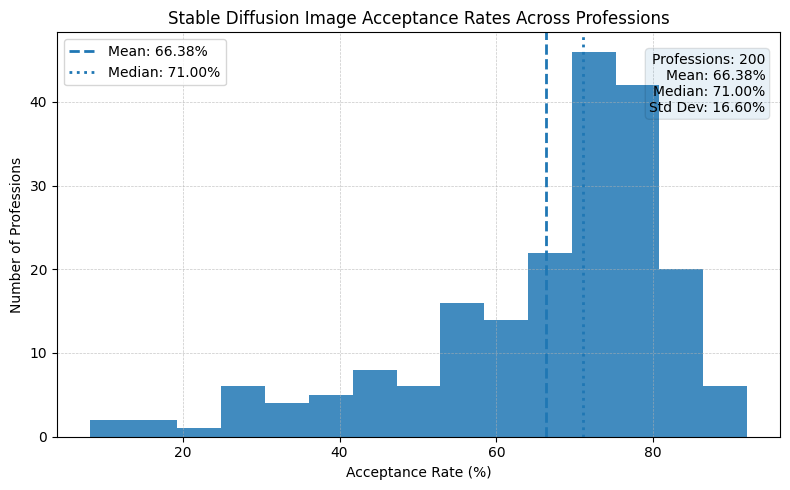

In [5]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# CONFIG
# ----------------------------
ROOT_DIR = Path(r"E:\ImageRetrieval\StableDiffusionGeneratedImages")
VALID_DIR = ROOT_DIR / "valid"
INVALID_DIR = ROOT_DIR / "invalid"

# ----------------------------
# HELPERS
# ----------------------------
def count_images(folder_path):
    if not folder_path.exists():
        return 0
    return sum(1 for f in folder_path.iterdir() if f.is_file())

# ----------------------------
# BUILD DATAFRAME
# ----------------------------
profession_names = set()

if VALID_DIR.exists():
    profession_names.update(p.name for p in VALID_DIR.iterdir() if p.is_dir())

if INVALID_DIR.exists():
    profession_names.update(p.name for p in INVALID_DIR.iterdir() if p.is_dir())

data = []

for profession in profession_names:
    valid_count = count_images(VALID_DIR / profession)
    invalid_count = count_images(INVALID_DIR / profession)
    total = valid_count + invalid_count

    if total == 0:
        continue

    acceptance_rate = (valid_count / total) * 100
    data.append((profession, acceptance_rate))

df = pd.DataFrame(data, columns=["profession", "acceptance_rate"])

# ----------------------------
# STATS
# ----------------------------
mean_val = df["acceptance_rate"].mean()
median_val = df["acceptance_rate"].median()
std_val = df["acceptance_rate"].std()

# ----------------------------
# HISTOGRAM
# ----------------------------
plt.figure(figsize=(8, 5))
plt.hist(df["acceptance_rate"], bins=15, alpha=0.85)

plt.axvline(mean_val, linestyle="--", linewidth=2, label=f"Mean: {mean_val:.2f}%")
plt.axvline(median_val, linestyle=":", linewidth=2, label=f"Median: {median_val:.2f}%")

plt.xlabel("Acceptance Rate (%)")
plt.ylabel("Number of Professions")
plt.title("Stable Diffusion Image Acceptance Rates Across Professions")

plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.legend()

stats_text = (
    f"Professions: {len(df)}\n"
    f"Mean: {mean_val:.2f}%\n"
    f"Median: {median_val:.2f}%\n"
    f"Std Dev: {std_val:.2f}%"
)

plt.text(
    0.98,
    0.95,
    stats_text,
    transform=plt.gca().transAxes,
    verticalalignment="top",
    horizontalalignment="right",
    bbox=dict(boxstyle="round", alpha=0.1)
)

plt.tight_layout()
plt.show()